<a href="https://colab.research.google.com/github/Demi-Khaled/DermaScan/blob/main/Project_ChestXRay_ResNet50_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 Chest X-Ray Pneumonia Classification
## CAI3105/CS460 - Deep Learning | 12th Week Project

### Comparative Study:
- **Approach 1:** ResNet50 (Feature Extractor) + SVM
- **Approach 2:** ResNet50 End-to-End (Fine-tuned)

---

> ☁️ **نسخة Google Colab**  
> قبل التشغيل: **Runtime → Change runtime type → T4 GPU** ثم اضغط Save

## ⚙️ الخطوة 0: إعداد الـ GPU على Colab

In [1]:
# ============================================================
# إعداد الـ GPU على Google Colab
# ============================================================
import sys
import subprocess
import os
import tensorflow as tf

print('=' * 60)
print('🔍 Colab GPU Check')
print('=' * 60)
print(f'📋 TensorFlow Version : {tf.__version__}')
print(f'📋 Python Version     : {sys.version.split()[0]}')

# --- فحص nvidia-smi ---
print()
print('🖥️  nvidia-smi:')
try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
         '--format=csv,noheader'],
        capture_output=True, text=True, timeout=10
    )
    if result.returncode == 0:
        print(f'   ✅ GPU Found : {result.stdout.strip()}')
    else:
        print('   ❌ لم يتم العثور على GPU')
        print('   👉 تأكد من: Runtime → Change runtime type → T4 GPU')
except Exception as e:
    print(f'   ⚠️ {e}')

# --- إعداد GPU Memory Growth ---
print()
print('⚙️  TensorFlow GPU Setup:')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'   ✅ GPU Memory Growth مفعّل')
        print(f'   ✅ GPU Devices: {[g.name for g in gpus]}')
    except RuntimeError as e:
        print(f'   ⚠️ {e} — أعد تشغيل الـ Runtime')
else:
    print('   ❌ لا يوجد GPU — اذهب إلى Runtime → Change runtime type → T4 GPU')

# --- GPU Compute Test ---
if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        _ = tf.matmul(a, a)
    print(f'   ✅ GPU Compute Test: PASSED')

DEVICE = '/GPU:0' if gpus else '/CPU:0'
print()
print('=' * 60)
print(f'📋 GPU Devices : {tf.config.list_physical_devices("GPU")}')
print(f'📋 CPU Devices : {tf.config.list_physical_devices("CPU")}')
print(f'🚀 سيعمل الكود على: {DEVICE}')
print('=' * 60)


🔍 Colab GPU Check
📋 TensorFlow Version : 2.20.0
📋 Python Version     : 3.12.13

🖥️  nvidia-smi:
   ✅ GPU Found : Tesla T4, 15360 MiB, 580.82.07

⚙️  TensorFlow GPU Setup:
   ✅ GPU Memory Growth مفعّل
   ✅ GPU Devices: ['/physical_device:GPU:0']
   ✅ GPU Compute Test: PASSED

📋 GPU Devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
📋 CPU Devices : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
🚀 سيعمل الكود على: /GPU:0


## 📥 الخطوة 0.5: تحميل Dataset من Kaggle

> **طريقتان للحصول على الداتا — اختر واحدة:**
>
> **الطريقة A (موصى بها):** رفع `kaggle.json` من حسابك على Kaggle  
> **الطريقة B:** رفع ملف ZIP يدوياً من جهازك
>
> للحصول على `kaggle.json`: اذهب إلى kaggle.com → اسمك → Settings → API → Create New Token

In [2]:
# ============================================================
# الطريقة A: تحميل الداتا عبر Kaggle API
# ============================================================
import os
from google.colab import files

USE_KAGGLE_API = True   # ← غيّرها لـ False لو هتستخدم الطريقة B

if USE_KAGGLE_API:
    print('📤 ارفع ملف kaggle.json:')
    uploaded = files.upload()   # ستظهر نافذة اختيار ملف

    # إعداد مجلد Kaggle
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    # تثبيت kaggle وتحميل الداتا
    !pip install kaggle -q
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    !unzip -q chest-xray-pneumonia.zip -d /content/
    print('✅ تم تحميل وفك ضغط الداتا بنجاح!')

else:
    # ============================================================
    # الطريقة B: رفع ZIP يدوياً
    # ============================================================
    print('📤 ارفع ملف chest-xray-pneumonia.zip:')
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    !unzip -q "{zip_name}" -d /content/
    print('✅ تم فك الضغط بنجاح!')


📤 ارفع ملف kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ تم تحميل وفك ضغط الداتا بنجاح!


## 📦 الخطوة 1: استيراد المكتبات

In [3]:
# ============================================================
# المكتبات الأساسية
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA

print(f'✅ TensorFlow Version: {tf.__version__}')
print(f'✅ GPU Available     : {tf.config.list_physical_devices("GPU")}')


✅ TensorFlow Version: 2.20.0
✅ GPU Available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🔧 الخطوة 2: إعداد الـ Hyperparameters

In [4]:
# ============================================================
# Hyperparameters - جميع الإعدادات في مكان واحد
# ============================================================
IMG_SIZE      = 224          # حجم الصورة (224x224) - مطلوب في ResNet50
BATCH_SIZE    = 32           # عدد الصور في كل batch
EPOCHS        = 10           # عدد مرات التدريب
LEARNING_RATE = 0.0001       # معدل التعلم
NUM_CLASSES   = 2            # Normal / Pneumonia

# ============================================================
# مسارات الداتا على Colab - يكتشف المسار تلقائياً
# ============================================================
def find_data_root():
    """يبحث تلقائياً عن مجلد chest_xray في /content/"""
    candidates = [
        '/content/chest_xray',
        '/content/chest-xray-pneumonia/chest_xray',
        '/content/chest_xray/chest_xray',
    ]
    for path in candidates:
        if os.path.isdir(os.path.join(path, 'train')):
            return path
    # بحث شامل كبديل أخير
    for root, dirs, _ in os.walk('/content'):
        if 'train' in dirs and 'test' in dirs:
            return root
    return None

DATA_ROOT = find_data_root()

if DATA_ROOT:
    TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
    VAL_DIR   = os.path.join(DATA_ROOT, 'val')
    TEST_DIR  = os.path.join(DATA_ROOT, 'test')
    print(f'✅ Data root found: {DATA_ROOT}')
else:
    print('❌ لم يتم العثور على الداتا — تأكد من تنفيذ خلية التحميل أولاً')

CLASSES = ['NORMAL', 'PNEUMONIA']

# مجلد حفظ النتائج على Colab
OUTPUT_DIR = '/content/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# التحقق من وجود الداتا
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    status = '✅' if os.path.exists(d) else '❌'
    print(f'{status} {d}')

# عرض جدول الـ Hyperparameters
params_df = pd.DataFrame({
    'Parameter': ['Image Size', 'Batch Size', 'Epochs', 'Learning Rate',
                  'Optimizer', 'Loss Function', 'SVM Kernel', 'Classes'],
    'Approach 1 (SVM)': ['224×224', str(BATCH_SIZE), 'N/A (Feature Extraction)',
                          'N/A', 'N/A', 'N/A', 'Linear', '2'],
    'Approach 2 (End-to-End)': ['224×224', str(BATCH_SIZE), str(EPOCHS), str(LEARNING_RATE),
                                 'Adam', 'Binary Crossentropy', 'N/A', '2']
})
print('\n📊 Hyperparameters Table:')
print(params_df.to_string(index=False))


✅ Data root found: /content/chest_xray
✅ /content/chest_xray/train
✅ /content/chest_xray/val
✅ /content/chest_xray/test

📊 Hyperparameters Table:
    Parameter         Approach 1 (SVM) Approach 2 (End-to-End)
   Image Size                  224×224                 224×224
   Batch Size                       32                      32
       Epochs N/A (Feature Extraction)                      10
Learning Rate                      N/A                  0.0001
    Optimizer                      N/A                    Adam
Loss Function                      N/A     Binary Crossentropy
   SVM Kernel                   Linear                     N/A
      Classes                        2                       2


## 🖼️ الخطوة 3: Data Preprocessing & Augmentation

In [5]:
# ============================================================
# Data Augmentation للـ Training
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Pixel Normalization: [0,255] -> [0,1]
    rotation_range=15,        # تدوير الصورة ±15 درجة
    width_shift_range=0.1,    # إزاحة أفقية 10%
    height_shift_range=0.1,   # إزاحة رأسية 10%
    horizontal_flip=True,     # قلب أفقي
    zoom_range=0.1,           # تكبير/تصغير 10%
    fill_mode='nearest'
)

# بدون Augmentation للـ Validation والـ Test
test_datagen = ImageDataGenerator(rescale=1./255)

# تحميل الصور
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', color_mode='rgb'
)

val_gen = test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', color_mode='rgb'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary',
    color_mode='rgb', shuffle=False
)

print(f'\n📊 Dataset Summary:')
print(f'   Training   : {train_gen.samples} images')
print(f'   Validation : {val_gen.samples} images')
print(f'   Testing    : {test_gen.samples} images')
print(f'   Classes    : {train_gen.class_indices}')


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

📊 Dataset Summary:
   Training   : 5216 images
   Validation : 16 images
   Testing    : 624 images
   Classes    : {'NORMAL': 0, 'PNEUMONIA': 1}


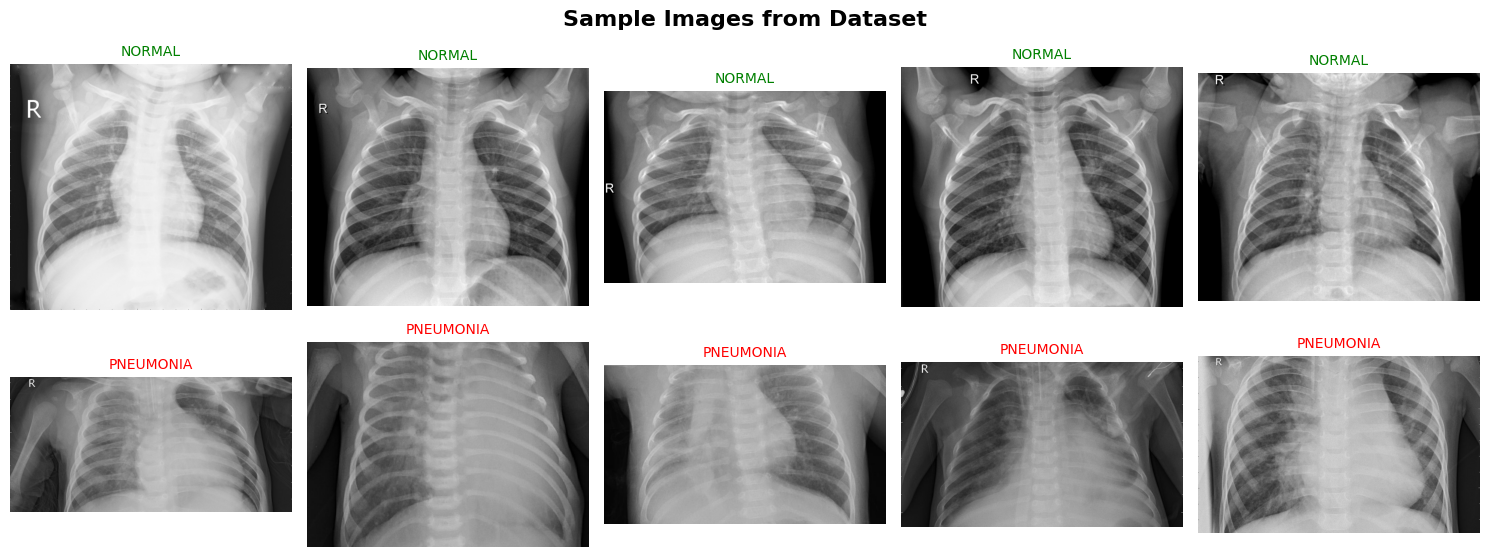

✅ Saved: /content/results/sample_images.png


In [6]:
# ============================================================
# عرض عينات من الداتا
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

for i, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    images = os.listdir(class_dir)[:5]
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = plt.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(class_name, fontsize=10,
                              color='green' if class_name=='NORMAL' else 'red')
        axes[i, j].axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'sample_images.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')


## 🔵 Approach 1: ResNet50 + SVM

In [7]:
# ============================================================
# APPROACH 1 - الخطوة 1: بناء Feature Extractor
# ============================================================
print('🔵 APPROACH 1: ResNet50 as Feature Extractor + SVM')
print('='*55)

# تحميل ResNet50 بدون الـ Top Layer (Classification Head)
base_model = ResNet50(
    weights='imagenet',    # أوزان مدربة على ImageNet
    include_top=False,     # إزالة آخر طبقة التصنيف
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# تجميد كل الأوزان (لا تدريب - فقط استخراج Features)
base_model.trainable = False

# إضافة Global Average Pooling للحصول على Feature Vector
feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

print(f'✅ Feature Extractor Output Shape: {feature_extractor.output_shape}')
print(f'   (كل صورة هتتحول لـ vector بحجم 2048)')


🔵 APPROACH 1: ResNet50 as Feature Extractor + SVM
✅ Feature Extractor Output Shape: (None, 2048)
   (كل صورة هتتحول لـ vector بحجم 2048)


In [8]:
# ============================================================
# APPROACH 1 - الخطوة 2: استخراج الـ Features
# ============================================================
import time

def extract_features(generator, model, steps):
    """استخراج Features من كل الصور"""
    features = []
    labels = []
    generator.reset()
    for i in range(steps):
        X_batch, y_batch = next(generator)
        feat = model.predict(X_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
        if (i+1) % 10 == 0:
            print(f'   Processed {(i+1)*BATCH_SIZE} images...')
    return np.vstack(features), np.concatenate(labels)

# استخراج features من Training Set
print('📤 Extracting Training Features...')
t1 = time.time()
train_steps = int(np.ceil(train_gen.samples / BATCH_SIZE))
X_train_feat, y_train = extract_features(train_gen, feature_extractor, train_steps)
print(f'✅ Train Features Shape: {X_train_feat.shape}')

# استخراج features من Test Set
print('\n📤 Extracting Test Features...')
test_steps = int(np.ceil(test_gen.samples / BATCH_SIZE))
X_test_feat, y_test = extract_features(test_gen, feature_extractor, test_steps)
feat_time = time.time() - t1
print(f'✅ Test Features Shape : {X_test_feat.shape}')
print(f'⏱️ Feature Extraction Time: {feat_time:.1f} seconds')


📤 Extracting Training Features...
   Processed 320 images...
   Processed 640 images...
   Processed 960 images...
   Processed 1280 images...
   Processed 1600 images...
   Processed 1920 images...
   Processed 2240 images...
   Processed 2560 images...
   Processed 2880 images...
   Processed 3200 images...
   Processed 3520 images...
   Processed 3840 images...
   Processed 4160 images...
   Processed 4480 images...
   Processed 4800 images...
   Processed 5120 images...
✅ Train Features Shape: (5216, 2048)

📤 Extracting Test Features...
   Processed 320 images...
   Processed 640 images...
✅ Test Features Shape : (624, 2048)
⏱️ Feature Extraction Time: 163.8 seconds


In [9]:
# ============================================================
# APPROACH 1 - الخطوة 3: تدريب SVM
# ============================================================
print('🤖 Training SVM Classifier...')

# Normalize الـ Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# تقليل الأبعاد بـ PCA (اختياري - يسرع التدريب)
pca = PCA(n_components=512, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f'   PCA: 2048 -> 512 features')

# تدريب SVM بـ Linear Kernel
t2 = time.time()
svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)
svm_train_time = time.time() - t2

# التنبؤ
y_pred_svm = svm_model.predict(X_test_pca)
print(f'✅ SVM Training Time: {svm_train_time:.1f} seconds')


🤖 Training SVM Classifier...
   PCA: 2048 -> 512 features
✅ SVM Training Time: 52.0 seconds


📊 APPROACH 1 RESULTS - ResNet50 + SVM
  Accuracy  : 80.45%
  Precision : 82.68%
  Recall    : 86.92%
  F1-Score  : 84.75%

              precision    recall  f1-score   support

      NORMAL       0.76      0.70      0.73       234
   PNEUMONIA       0.83      0.87      0.85       390

    accuracy                           0.80       624
   macro avg       0.79      0.78      0.79       624
weighted avg       0.80      0.80      0.80       624



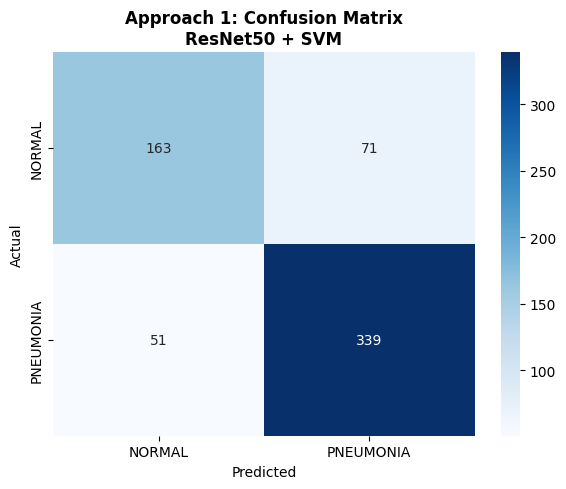

In [10]:
# ============================================================
# APPROACH 1 - الخطوة 4: تقييم النتائج
# ============================================================
print('📊 APPROACH 1 RESULTS - ResNet50 + SVM')
print('='*45)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)
cm_svm   = confusion_matrix(y_test, y_pred_svm)

print(f'  Accuracy  : {acc_svm*100:.2f}%')
print(f'  Precision : {prec_svm*100:.2f}%')
print(f'  Recall    : {rec_svm*100:.2f}%')
print(f'  F1-Score  : {f1_svm*100:.2f}%')
print(f'\n{classification_report(y_test, y_pred_svm, target_names=CLASSES)}')

# رسم Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Approach 1: Confusion Matrix\nResNet50 + SVM', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_approach1.png'), dpi=150, bbox_inches='tight')
plt.show()


## 🔴 Approach 2: ResNet50 End-to-End

In [11]:
# ============================================================
# APPROACH 2 - الخطوة 1: بناء الـ Model الكامل
# ============================================================
print('🔴 APPROACH 2: ResNet50 End-to-End (Fine-tuning)')
print('='*55)

def build_resnet50_model():
    """بناء ResNet50 مع Classification Head"""
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # تجميد أول 100 طبقة
    for layer in base.layers[:100]:
        layer.trainable = False
    for layer in base.layers[100:]:
        layer.trainable = True

    # بناء الـ Classification Head
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')   # Binary Classification
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

gpus = tf.config.list_physical_devices('GPU')
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    e2e_model = build_resnet50_model()

print(f'✅ Model Built Successfully')
print(f'   Total Parameters    : {e2e_model.count_params():,}')
trainable = sum([tf.size(w).numpy() for w in e2e_model.trainable_weights])
print(f'   Trainable Parameters: {trainable:,}')
print(f'   Running on          : {"GPU" if gpus else "CPU"}')


🔴 APPROACH 2: ResNet50 End-to-End (Fine-tuning)
✅ Model Built Successfully
   Total Parameters    : 24,112,513
   Trainable Parameters: 19,977,729
   Running on          : GPU


In [12]:
# ============================================================
# APPROACH 2 - الخطوة 2: تدريب الـ Model
# ============================================================

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=3,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-7, verbose=1
)

print('🏋️ Training End-to-End Model...')
t3 = time.time()

history = e2e_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

e2e_train_time = time.time() - t3
print(f'\n✅ Training Completed in {e2e_train_time:.1f} seconds')


🏋️ Training End-to-End Model...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 682ms/step - accuracy: 0.8825 - loss: 0.2725 - val_accuracy: 0.5000 - val_loss: 20.2273 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.9128 - loss: 0.2139 - val_accuracy: 0.8125 - val_loss: 0.5880 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.9201 - loss: 0.1968 - val_accuracy: 0.5000 - val_loss: 7.0012 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 648ms/step - accuracy: 0.9247 - loss: 0.1775 - val_accuracy: 0.6875 - val_loss: 0.5321 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 657ms/step - accuracy: 0.9325 - loss: 0.1745 - val_accuracy: 0.5000 - val_loss: 3.3437 - learning_rate: 1.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

✅ Training Completed in 573.3 seconds


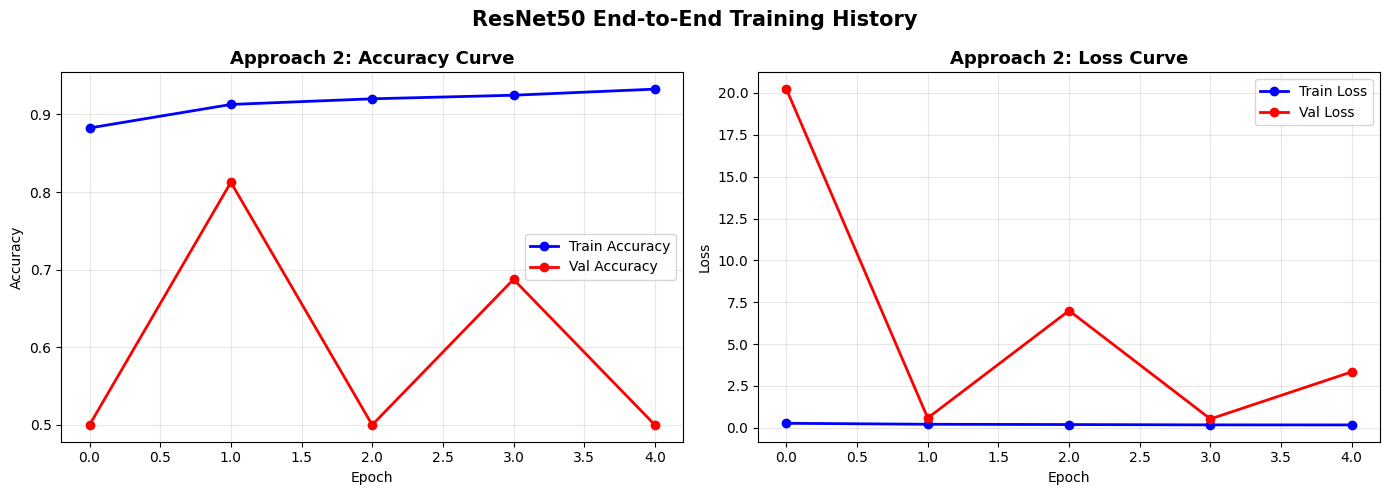

In [13]:
# ============================================================
# APPROACH 2 - الخطوة 3: رسم Learning Curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
ax1.plot(history.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], 'r-o', label='Val Accuracy', linewidth=2)
ax1.set_title('Approach 2: Accuracy Curve', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss Curve
ax2.plot(history.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
ax2.set_title('Approach 2: Loss Curve', fontweight='bold', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet50 End-to-End Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


📊 APPROACH 2 RESULTS - ResNet50 End-to-End
  Accuracy  : 84.78%
  Precision : 85.54%
  Recall    : 91.03%
  F1-Score  : 88.20%

              precision    recall  f1-score   support

      NORMAL       0.83      0.74      0.79       234
   PNEUMONIA       0.86      0.91      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.83      0.83       624
weighted avg       0.85      0.85      0.85       624



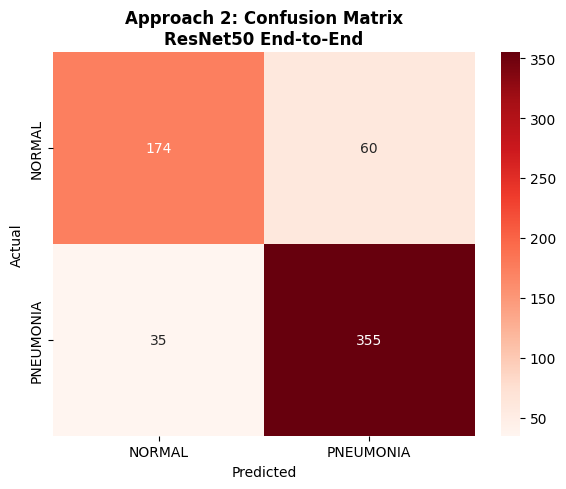

In [14]:
# ============================================================
# APPROACH 2 - الخطوة 4: تقييم النتائج
# ============================================================
print('📊 APPROACH 2 RESULTS - ResNet50 End-to-End')
print('='*45)

# التنبؤ
test_gen.reset()
y_pred_proba = e2e_model.predict(test_gen, verbose=0)
y_pred_e2e   = (y_pred_proba > 0.5).astype(int).flatten()
y_true       = test_gen.classes

acc_e2e  = accuracy_score(y_true, y_pred_e2e)
prec_e2e = precision_score(y_true, y_pred_e2e)
rec_e2e  = recall_score(y_true, y_pred_e2e)
f1_e2e   = f1_score(y_true, y_pred_e2e)
cm_e2e   = confusion_matrix(y_true, y_pred_e2e)

print(f'  Accuracy  : {acc_e2e*100:.2f}%')
print(f'  Precision : {prec_e2e*100:.2f}%')
print(f'  Recall    : {rec_e2e*100:.2f}%')
print(f'  F1-Score  : {f1_e2e*100:.2f}%')
print(f'\n{classification_report(y_true, y_pred_e2e, target_names=CLASSES)}')

# رسم Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_e2e, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Approach 2: Confusion Matrix\nResNet50 End-to-End', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_approach2.png'), dpi=150, bbox_inches='tight')
plt.show()


## 📊 Comparative Analysis (Requirement 4)

📊 FINAL COMPARATIVE ANALYSIS
           Metric Approach 1 (ResNet50 + SVM) Approach 2 (End-to-End)
         Accuracy                      80.45%                  84.78%
        Precision                      82.68%                  85.54%
           Recall                      86.92%                  91.03%
         F1-Score                      84.75%                  88.20%
Training Time (s)                       52.0s                  573.3s


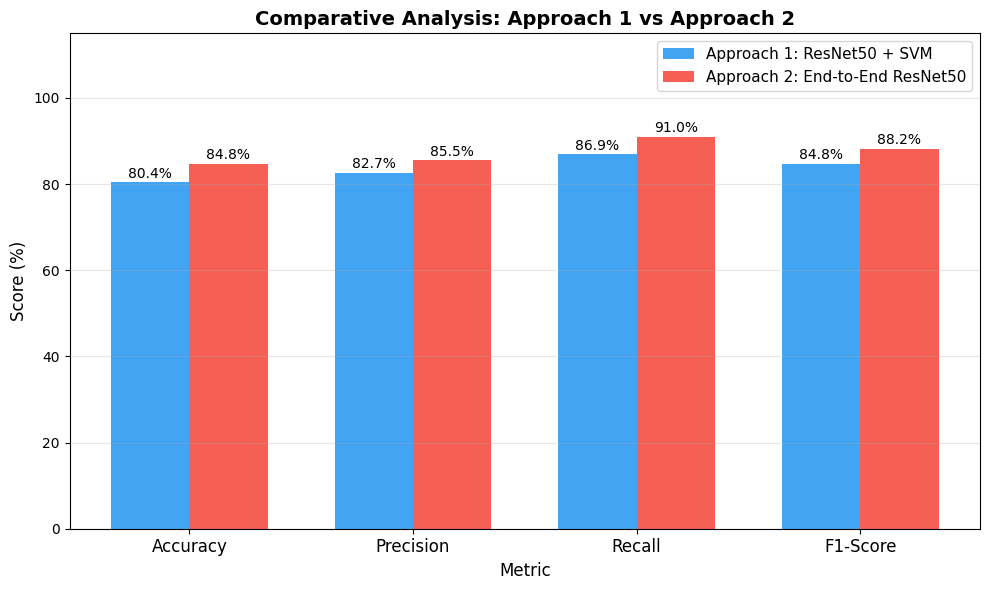


✅ All results saved successfully!


In [15]:
# ============================================================
# المقارنة النهائية بين الـ Approaches
# ============================================================
print('📊 FINAL COMPARATIVE ANALYSIS')
print('='*50)

# جدول المقارنة
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)'],
    'Approach 1 (ResNet50 + SVM)': [
        f'{acc_svm*100:.2f}%', f'{prec_svm*100:.2f}%',
        f'{rec_svm*100:.2f}%', f'{f1_svm*100:.2f}%',
        f'{svm_train_time:.1f}s'
    ],
    'Approach 2 (End-to-End)': [
        f'{acc_e2e*100:.2f}%', f'{prec_e2e*100:.2f}%',
        f'{rec_e2e*100:.2f}%', f'{f1_e2e*100:.2f}%',
        f'{e2e_train_time:.1f}s'
    ]
})
print(results_df.to_string(index=False))

# رسم Bar Chart للمقارنة
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [acc_svm, prec_svm, rec_svm, f1_svm]
e2e_scores = [acc_e2e, prec_e2e, rec_e2e, f1_e2e]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [s*100 for s in svm_scores],
               width, label='Approach 1: ResNet50 + SVM',
               color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, [s*100 for s in e2e_scores],
               width, label='Approach 2: End-to-End ResNet50',
               color='#F44336', alpha=0.85)

# إضافة القيم فوق الـ bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparative Analysis: Approach 1 vs Approach 2',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ All results saved successfully!')


In [16]:
# ============================================================
# تحميل النتائج من Colab إلى جهازك
# ============================================================
from google.colab import files
import zipfile

result_files = [
    'sample_images.png', 'cm_approach1.png',
    'cm_approach2.png', 'learning_curves.png', 'comparison_chart.png'
]

print(f'📁 النتائج في: {OUTPUT_DIR}')
print('='*50)

# فحص الملفات
for fname in result_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  ✅ {fname:30s} ({size_kb:.1f} KB)')
    else:
        print(f'  ❌ {fname:30s} (لم يتم الحفظ)')

# ضغط كل النتائج في ZIP وتحميلها دفعة واحدة
zip_path = '/content/results.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in result_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)

print('\n📥 جاري تحميل ملف النتائج...')
files.download(zip_path)
print('🎉 Project Complete!')


📁 النتائج في: /content/results
  ✅ sample_images.png              (956.7 KB)
  ✅ cm_approach1.png               (38.3 KB)
  ✅ cm_approach2.png               (40.9 KB)
  ✅ learning_curves.png            (102.9 KB)
  ✅ comparison_chart.png           (65.6 KB)

📥 جاري تحميل ملف النتائج...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Project Complete!
